#### Classification - homework

#### 1. Data Preparation

In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv('https://raw.githubusercontent.com/alexeygrigorev/datasets/master/course_lead_scoring.csv')

In [4]:
df

,lead_source,industry,number_of_courses_viewed,annual_income,employment_status,location,interaction_count,lead_score,converted
0,paid_ads,NaN,1,79450.0,unemployed,south_america,4,0.94,1
1,social_media,retail,1,46992.0,employed,south_america,1,0.80,0
2,events,healthcare,5,78796.0,unemployed,australia,3,0.69,1
3,paid_ads,retail,2,83843.0,NaN,australia,1,0.87,0
4,referral,education,3,85012.0,self_employed,europe,3,0.62,1
...,...,...,...,...,...,...,...,...,...
1457,referral,manufacturing,1,NaN,self_employed,north_america,4,0.53,1
1458,referral,technology,3,65259.0,student,europe,2,0.24,1
1459,paid_ads,technology,1,45688.0,student,north_america,3,0.02,1
1460,referral,NaN,5,71016.0,self_employed,north_america,0,0.25,1


In [7]:
df.dtypes

lead_source                     str
industry                        str
number_of_courses_viewed      int64
annual_income               float64
employment_status               str
location                        str
interaction_count             int64
lead_score                  float64
converted                     int64
dtype: object

In [6]:
df.isna().sum()

lead_source                 128
industry                    134
number_of_courses_viewed      0
annual_income               181
employment_status           100
location                     63
interaction_count             0
lead_score                    0
converted                     0
dtype: int64

In [13]:
cat = ['lead_source', 'industry', 'employment_status', 'location']
num = ['number_of_courses_viewed', 'annual_income', 'interaction_count', 'lead_score']

In [14]:
for c in cat:
    df[c] = df[c].fillna('NA')
for n in num:
    df[n] = df[n].fillna(0)

In [15]:
df.industry.value_counts()

industry
retail           203
finance          200
other            198
healthcare       187
education        187
technology       179
manufacturing    174
NA               134
Name: count, dtype: int64

In [16]:
df.corr(numeric_only=True)

,number_of_courses_viewed,annual_income,interaction_count,lead_score,converted
number_of_courses_viewed,1.000000,0.009770,-0.023565,-0.004879,0.435914
annual_income,0.009770,1.000000,0.027036,0.015610,0.053131
interaction_count,-0.023565,0.027036,1.000000,0.009888,0.374573
lead_score,-0.004879,0.015610,0.009888,1.000000,0.193673
converted,0.435914,0.053131,0.374573,0.193673,1.000000


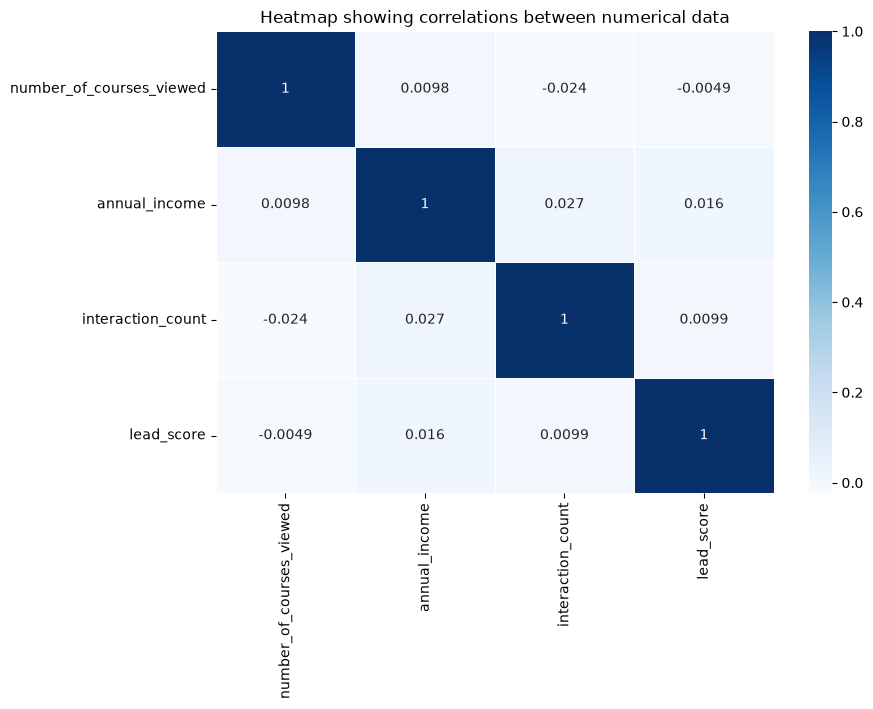

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(9, 6))
sns.heatmap(df[num].corr(),annot=True,linewidths=.5, cmap="Blues")
plt.title('Heatmap showing correlations between numerical data')
plt.show()

In [66]:
df[num].corr().unstack().sort_values(ascending=False)

number_of_courses_viewed  number_of_courses_viewed    1.000000
annual_income             annual_income               1.000000
lead_score                lead_score                  1.000000
interaction_count         interaction_count           1.000000
annual_income             interaction_count           0.027036
interaction_count         annual_income               0.027036
lead_score                annual_income               0.015610
annual_income             lead_score                  0.015610
lead_score                interaction_count           0.009888
interaction_count         lead_score                  0.009888
annual_income             number_of_courses_viewed    0.009770
number_of_courses_viewed  annual_income               0.009770
lead_score                number_of_courses_viewed   -0.004879
number_of_courses_viewed  lead_score                 -0.004879
                          interaction_count          -0.023565
interaction_count         number_of_courses_viewed   -0

In [19]:
from sklearn.model_selection import train_test_split

In [22]:
train_full_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

In [23]:
train_df, val_df = train_test_split(train_full_df, test_size=0.25, random_state=42)

In [24]:
train_full_df = train_full_df.reset_index(drop=True)
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

In [25]:
y_full_train = train_full_df.converted
y_train = train_df.converted
y_val = val_df.converted
y_test = test_df.converted

In [27]:
del train_full_df['converted']
del train_df['converted']
del val_df['converted']
del test_df['converted']

In [28]:
from sklearn.metrics import mutual_info_score
for c in cat:
    print(c, round(mutual_info_score(y_train, train_df[c]), 2))

lead_source 0.04
industry 0.01
employment_status 0.01
location 0.0


#### 2. Training logistic regression

In [124]:
from sklearn.feature_extraction import DictVectorizer

In [125]:
train_dict = train_df.to_dict(orient='records')
val_dict = val_df.to_dict(orient='records')
test_dict = test_df.to_dict(orient='records')

In [126]:
dv = DictVectorizer(sparse=False)

In [127]:
X_train = dv.fit_transform(train_dict)
X_val = dv.transform(val_dict)
X_test = dv.transform(test_dict)

In [128]:
dv.get_feature_names_out()

array(['annual_income', 'employment_status=NA',
       'employment_status=employed', 'employment_status=self_employed',
       'employment_status=student', 'employment_status=unemployed',
       'industry=NA', 'industry=education', 'industry=finance',
       'industry=healthcare', 'industry=manufacturing', 'industry=other',
       'industry=retail', 'industry=technology', 'interaction_count',
       'lead_score', 'lead_source=NA', 'lead_source=events',
       'lead_source=organic_search', 'lead_source=paid_ads',
       'lead_source=referral', 'lead_source=social_media', 'location=NA',
       'location=africa', 'location=asia', 'location=australia',
       'location=europe', 'location=middle_east',
       'location=north_america', 'location=south_america',
       'number_of_courses_viewed'], dtype=object)

In [129]:
from sklearn.linear_model import LogisticRegression

In [130]:
model = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
model.fit(X_train, y_train)

d:\Projects\ML-Zoomcamp\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [131]:
y_train_prob = model.predict_proba(X_train)[:, 1]
y_train_pred = (y_train_prob >= 0.5).astype(int)

In [132]:
(y_train == y_train_pred).mean()

np.float64(0.8732876712328768)

In [133]:
y_test_prob = model.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_prob >= 0.5).astype(int)

In [134]:
(y_test == y_test_pred).mean()

np.float64(0.8293515358361775)

In [135]:
y_val_prob = model.predict_proba(X_val)[:, 1]
y_val_pred = (y_val_prob >= 0.5).astype(int)

In [136]:
(y_val == y_val_pred).mean()

np.float64(0.8532423208191127)

In [137]:
from sklearn.metrics import accuracy_score

In [138]:
print(round(accuracy_score(y_train, y_train_pred), 2))

0.87


In [139]:
print(round(accuracy_score(y_val, y_val_pred), 2))
original_accuracy = accuracy_score(y_val, y_val_pred)

0.85


In [140]:
print(round(accuracy_score(y_test, y_test_pred), 2))

0.83


In [141]:
list(zip(dv.get_feature_names_out(), model.coef_[0].round(3)))

[('annual_income', np.float64(0.0)),
 ('employment_status=NA', np.float64(-0.43)),
 ('employment_status=employed', np.float64(0.671)),
 ('employment_status=self_employed', np.float64(-0.018)),
 ('employment_status=student', np.float64(-0.218)),
 ('employment_status=unemployed', np.float64(-1.761)),
 ('industry=NA', np.float64(-0.416)),
 ('industry=education', np.float64(0.861)),
 ('industry=finance', np.float64(-0.255)),
 ('industry=healthcare', np.float64(-0.534)),
 ('industry=manufacturing', np.float64(-0.146)),
 ('industry=other', np.float64(-0.337)),
 ('industry=retail', np.float64(-0.687)),
 ('industry=technology', np.float64(-0.24)),
 ('interaction_count', np.float64(1.058)),
 ('lead_score', np.float64(3.08)),
 ('lead_source=NA', np.float64(0.185)),
 ('lead_source=events', np.float64(-0.414)),
 ('lead_source=organic_search', np.float64(-0.356)),
 ('lead_source=paid_ads', np.float64(-1.813)),
 ('lead_source=referral', np.float64(1.402)),
 ('lead_source=social_media', np.float64(-0

#### Features elimination

In [142]:
features = train_df.columns.to_list()

In [143]:
features

['lead_source',
 'industry',
 'number_of_courses_viewed',
 'annual_income',
 'employment_status',
 'location',
 'interaction_count',
 'lead_score']

In [144]:
eliminate = ['industry', 'employment_status', 'lead_score']

In [145]:
results = pd.DataFrame(columns=['feature', 'val_acc', 'original - val_acc'])
for feature in eliminate:
    subset = features.copy()
    subset.remove(feature)

    train_dict = train_df[subset].to_dict(orient='records')
    val_dict = val_df[subset].to_dict(orient='records')

    X_train = dv.fit_transform(train_dict)
    X_val = dv.transform(val_dict)

    model = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
    model.fit(X_train, y_train)

    val_pred = model.predict(X_val)
    val_acc = accuracy_score(y_val, val_pred)
    results.loc[len(results)] = {
        'feature': feature,
        'val_acc': val_acc,
        'original - val_acc': original_accuracy - val_acc
    }



d:\Projects\ML-Zoomcamp\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
d:\Projects\ML-Zoomcamp\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html


In [146]:
results

,feature,val_acc,original - val_acc
0,industry,0.846416,0.006826
1,employment_status,0.832765,0.020478
2,lead_score,0.819113,0.034130


In [147]:
results[results['original - val_acc'] == results['original - val_acc'].min()]

,feature,val_acc,original - val_acc
0,industry,0.846416,0.006826


#### Regularized logistics regression

In [149]:
C = [0.01, 0.1, 1.0, 10.0, 100.0]
results = pd.DataFrame(columns=['C', 'val_acc', 'original - val_acc'])
for c in C:
    train_dict = train_df.to_dict(orient='records')
    val_dict = val_df.to_dict(orient='records')

    X_train = dv.fit_transform(train_dict)
    X_val = dv.transform(val_dict)

    model = LogisticRegression(C=c, max_iter=1000, random_state=42)
    model.fit(X_train, y_train)

    val_pred = model.predict(X_val)
    val_acc = accuracy_score(y_val, val_pred)
    results.loc[len(results)] = {
        'C': c,
        'val_acc': val_acc,
        'original - val_acc': original_accuracy - val_acc
    }

print(results)

d:\Projects\ML-Zoomcamp\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
d:\Projects\ML-Zoomcamp\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html


        C   val_acc  original - val_acc
0    0.01  0.812287            0.040956
1    0.10  0.843003            0.010239
2    1.00  0.853242            0.000000
3   10.00  0.853242            0.000000
4  100.00  0.853242            0.000000
